<a href="https://colab.research.google.com/github/DIFACQUIM/Cursos/blob/main/5_3_Curado_de_bases_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is an english traduction of the original notebook developed by the Difacquim Group available at: "https://github.com/DIFACQUIM/Cursos/blob/main/5_3_Curado_de_bases_de_datos.ipynb"



#Environment Setup



In [ ]:
#Install RDKit
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 34.8 MB/s eta 0:00:00


In [ ]:
#Install MolVS
!pip install -q molvs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
#Install Rectifier, requieres RDKit
!pip install molecular-rectifier

  Preparing metadata (setup.py) ... done
  Created wheel for molecular-rectifier: filename=molecular_rectifier-1.0.1-py3-none-any.whl size=19470 sha256=58fb9d9e87bcdd2c9e1bdc05275c5326a607fae48504efc4c606a9b671357852
  Stored in directory: /root/.cache/pip/wheels/13/a9/91/728ab4f343264cd1e1afa1c110bb952561b8722a67fb3feb1b
Successfully built molecular-rectifier


In [ ]:
#Import libraries
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import MolStandardize
from rdkit.Chem import rdmolops
from molvs.standardize import Standardizer
from molvs.charge import Uncharger, Reionizer
from molvs.fragment import LargestFragmentChooser
from molvs.tautomer import TautomerCanonicalizer
from rdkit.Chem.rdmolops import GetFormalCharge, RemoveStereochemistry
from molecular_rectifier import Rectifier

#Molecular Rectifier

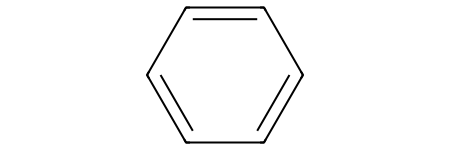

In [ ]:
mol = Chem.MolFromSmiles("C1=CC=CC=C1", sanitize=False)
mol

In [ ]:
recto = Rectifier(mol, valence_correction='charge')
recto.fix_issues()  # Rectifica valencias
fixed_mol = recto.mol
Chem.SanitizeMol(fixed_mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL)
Chem.MolToSmiles(fixed_mol)

'c1ccccc1'

In [ ]:
mol = Chem.MolFromSmiles("c1cccn(C)c1")
mol

[20:32:23] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 6


In [ ]:
mol = Chem.MolFromSmiles("c1cccn(C)c1", sanitize=False)
Chem.MolToSmiles(mol)

'Cn1ccccc1'

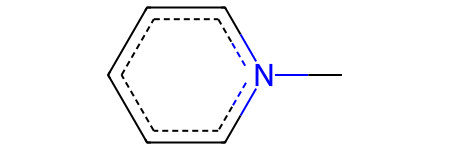

In [ ]:
mol

In [ ]:
recto = Rectifier(mol, valence_correction='charge')
recto.fix_issues()
fixed_mol = recto.mol
Chem.SanitizeMol(fixed_mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL)
Chem.MolToSmiles(fixed_mol)

[20:32:30] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 6
[20:32:30] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 6
[20:32:30] Explicit valence for atom # 4 N, 5, is greater than permitted
[20:32:30] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 6
[20:32:30] Explicit valence for atom # 4 N, 5, is greater than permitted
[20:32:30] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 6


'C[n+]1ccccc1'

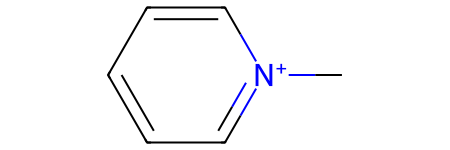

In [ ]:
fixed_mol

#MolVS Funtions

In [ ]:
STD = Standardizer() # Versión estandarizada de la notación SMILES.
LFC = LargestFragmentChooser() # Selecciona el fragmento más grande en el caso de sales.
UC = Uncharger() # Añade/elimina hidrógenos para neutralizar la molécula.
RI = Reionizer() # Ionizar primero al ácido más fuerte.
TC = TautomerCanonicalizer()  # Tautómero canónico.

##*Standardizer*

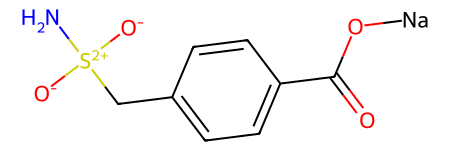

In [ ]:
mol = Chem.MolFromSmiles('N[S++]([O-])([O-])Cc1ccc(cc1)C(=O)O[Na]')
mol

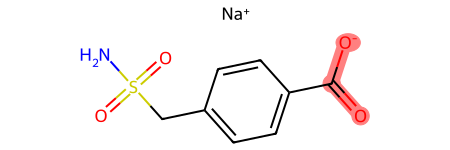

In [ ]:
smol = STD(mol)
smol

##*Largest Fragment Chooser*

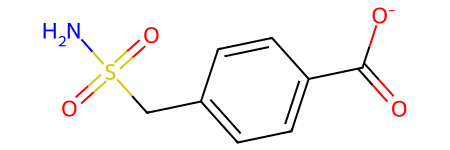

In [ ]:
lmol = LFC(smol)
lmol

##*Uncharger*

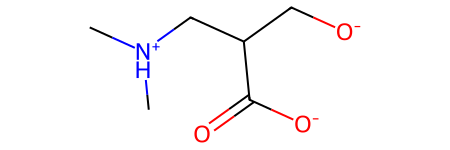

In [ ]:
mol2 = Chem.MolFromSmiles('[O-]CC(C(=O)[O-])C[NH+](C)C')
mol2

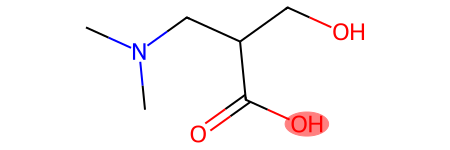

In [ ]:
umol2 = UC(mol2)
umol2

##*Reionizer*

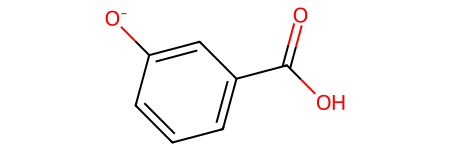

In [ ]:
mol3 = Chem.MolFromSmiles('c1ccc([O-])cc1C(=O)O')
mol3

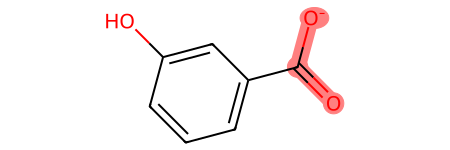

In [ ]:
rmol3 = RI(mol3)
rmol3

##*Tautomer Canonicalizer*

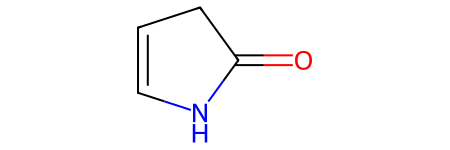

In [ ]:
mol4 = Chem.MolFromSmiles('O=C1CC=CN1')
mol4

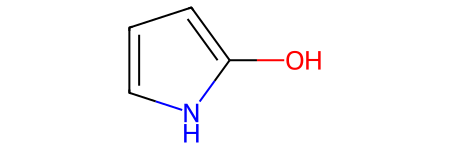

In [ ]:
tmol4 = TC(mol4)
tmol4

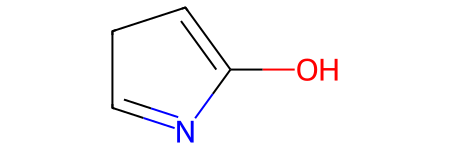

In [ ]:
mol5 = Chem.MolFromSmiles('OC1=CCC=N1')
mol5

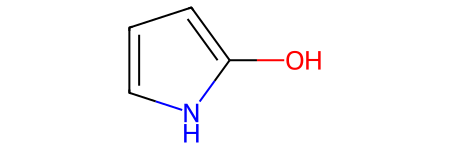

In [ ]:
tmol5 = TC(mol5)
tmol5

#Databases

In [ ]:
#Load database
url ="/content/Tau-DS.csv"
#df = pd.read_excel(url, index_col=0)  #Archivo formato excel
df = pd.read_csv(url)
df.head(2) # Show first thow rows

,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Molecule Max Phase,Activity µM,canonical_smiles
0,CHEMBL1378812,NaN,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,Potency,'=',100.0,nM,Active,NaN,0.10,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1
1,CHEMBL1518905,NaN,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,Potency,'=',125.9,nM,Active,NaN,0.13,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...


In [ ]:
#Print dataframe columns
print(df.columns)

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units', 'Comment',
       'Molecule Max Phase', 'Activity µM', 'canonical_smiles'],
      dtype='object')


In [ ]:
#Column Selection
data = df[['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units', 'Comment',
       'Molecule Max Phase', 'Activity µM', 'canonical_smiles']]
data

,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Molecule Max Phase,Activity µM,canonical_smiles
0,CHEMBL1378812,NaN,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,Potency,'=',100.0,nM,Active,NaN,0.10,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1
1,CHEMBL1518905,NaN,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,Potency,'=',125.9,nM,Active,NaN,0.13,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...
2,CHEMBL1607905,NaN,Cc1cc(-c2ccc(/N=N\c3ccc4c(S(=O)(=O)O)cc(S(=O)(...,Potency,'=',190.0,nM,Active,NaN,0.19,Cc1cc(-c2ccc(/N=N\c3ccc4c(S(=O)(=O)O)cc(S(=O)(...
3,CHEMBL1521960,NaN,CN1/C(=C\C=C\C2=[N+](C)c3ccc4ccccc4c3C2(C)C)C(...,Potency,'=',316.2,nM,Active,NaN,0.32,CN1/C(=C\C=C\C2=[N+](C)c3ccc4ccccc4c3C2(C)C)C(...
4,CHEMBL1573754,NaN,CCC(/C=C1\Sc2ccc(OC)cc2N1CCO)=C\c1sc2ccc(OC)cc...,Potency,'=',398.1,nM,Active,NaN,0.40,CCC(/C=C1\Sc2ccc(OC)cc2N1CCO)=C\c1sc2ccc(OC)cc...
...,...,...,...,...,...,...,...,...,...,...,...
5217,CHEMBL570408,"1,4-DIMETHOXYANTHRAQUINONE",COc1ccc(OC)c2c1C(=O)c1ccccc1C2=O,Potency,'=',35481.3,nM,Active,NaN,35.48,COc1ccc(OC)c2c1C(=O)c1ccccc1C2=O
5218,CHEMBL3144987,NaN,CC(C)(C)c1cc(=O)n(-c2ccccc2)[nH]1,Potency,'=',39810.7,nM,Active,NaN,39.81,CC(C)(C)c1cc(=O)n(-c2ccccc2)[nH]1
5219,CHEMBL1346032,NaN,N#CC1=C(S)N(c2ccc(F)cc2)C(c2ccco2)NC1=O,Potency,'=',39810.7,nM,Active,NaN,39.81,N#CC1=C(S)N(c2ccc(F)cc2)C(c2ccco2)NC1=O
5220,CHEMBL1363763,NaN,COCCOC(=O)C1=C(C)OC(N)=C(C(=O)OC)C12C(=O)Nc1cc...,Potency,'=',39810.7,nM,Active,NaN,39.81,COCCOC(=O)C1=C(C)OC(N)=C(C(=O)OC)C12C(=O)Nc1cc...


In [ ]:
data.tail(2)

,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Molecule Max Phase,Activity µM,canonical_smiles
5220,CHEMBL1363763,NaN,COCCOC(=O)C1=C(C)OC(N)=C(C(=O)OC)C12C(=O)Nc1cc...,Potency,'=',39810.7,nM,Active,NaN,39.81,COCCOC(=O)C1=C(C)OC(N)=C(C(=O)OC)C12C(=O)Nc1cc...
5221,CHEMBL1314077,NaN,OC[C@@H]1[C@@H](c2ccc(F)cc2)C(c2cccc(Cl)c2)=NN...,Potency,'=',39810.7,nM,Active,NaN,39.81,OC[C@@H]1[C@@H](c2ccc(F)cc2)C(c2cccc(Cl)c2)=NN...


In [ ]:

data.shape

(5222, 11)

#Database curation

In [ ]:
#Data Curation Function
def pretreatment(smi):
    try:
        mol = Chem.MolFromSmiles(smi, sanitize=False)
        if mol == None:
              #Error 1: RDKit SMILES Parsing Failure
            return "Error 1"
        else:
            recto = Rectifier(mol, valence_correction='charge')
            recto.fix_issues()
            fixed_mol = recto.mol
            Chem.SanitizeMol(fixed_mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL)

            fixed_mol = Chem.RemoveHs(fixed_mol) #Delete hydrogens

            fixed_mol = Chem.MolStandardize.rdMolStandardize.DisconnectOrganometallics(fixed_mol) #Metal-Salt Disconnection
            fixed_mol = Chem.MolStandardize.rdMolStandardize.Normalize(fixed_mol)

            fixed_mol = LFC(fixed_mol) #Largest Fragment Retention


            allowed_elements = {"H","B","C","N","O","F","Si","P","S","Cl","Se","Br","I"} #Allowed atoms
            actual_elements = set([atom.GetSymbol() for atom in fixed_mol.GetAtoms()])
            if len(actual_elements-allowed_elements) == 0:
                fixed_mol = UC(fixed_mol) #Charge Verification
                fixed_mol = RI(fixed_mol)
                #RemoveStereochemistry(mol)
                return Chem.MolToSmiles(fixed_mol)
            else:
                # Error 2: Presence of non targeted atoms
                return "Error 2"

    except:
        return "Something else was found"

In [ ]:
#New SMILES column
data["NEW_SMILES"] = [pretreatment(x) for x in data["Smiles"]]
data.head()

Se han truncado las últimas 5000 líneas del flujo de salida.
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnector
[20:40:43] Initializing Normalizer
[20:40:43] Running Normalizer
[20:40:43] Initializing MetalDisconnector
[20:40:43] Running MetalDisconnec

,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Molecule Max Phase,Activity µM,canonical_smiles,NEW_SMILES
0,CHEMBL1378812,NaN,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,Potency,'=',100.0,nM,Active,NaN,0.10,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1
1,CHEMBL1518905,NaN,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,Potency,'=',125.9,nM,Active,NaN,0.13,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...
2,CHEMBL1607905,NaN,Cc1cc(-c2ccc(/N=N\c3ccc4c(S(=O)(=O)O)cc(S(=O)(...,Potency,'=',190.0,nM,Active,NaN,0.19,Cc1cc(-c2ccc(/N=N\c3ccc4c(S(=O)(=O)O)cc(S(=O)(...,Cc1cc(-c2ccc(/N=N\c3ccc4c(S(=O)(=O)O)cc(S(=O)(...
3,CHEMBL1521960,NaN,CN1/C(=C\C=C\C2=[N+](C)c3ccc4ccccc4c3C2(C)C)C(...,Potency,'=',316.2,nM,Active,NaN,0.32,CN1/C(=C\C=C\C2=[N+](C)c3ccc4ccccc4c3C2(C)C)C(...,CN1/C(=C\C=C\C2=[N+](C)c3ccc4ccccc4c3C2(C)C)C(...
4,CHEMBL1573754,NaN,CCC(/C=C1\Sc2ccc(OC)cc2N1CCO)=C\c1sc2ccc(OC)cc...,Potency,'=',398.1,nM,Active,NaN,0.40,CCC(/C=C1\Sc2ccc(OC)cc2N1CCO)=C\c1sc2ccc(OC)cc...,CCC(/C=C1\Sc2ccc(OC)cc2N1CCO)=C\c1sc2ccc(OC)cc...


In [ ]:
# Removal of RDKit-unreadable SMILES
data = data[data["NEW_SMILES"] != "Error 1"]
# Removal of SMILES containing non-permitted atoms
data = data[data["NEW_SMILES"] != "Error 2"]
# Removal of other errors
data = data[data["NEW_SMILES"] != "Something else was found"].reset_index(drop=True)

In [ ]:
# Duplicates deletion
data = data.drop_duplicates(subset=["NEW_SMILES"], keep="first").reset_index(drop=True)
print(data.shape)
data.head(2)

(5211, 12)


,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units,Comment,Molecule Max Phase,Activity µM,canonical_smiles,NEW_SMILES
0,CHEMBL1378812,NaN,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,Potency,'=',100.0,nM,Active,NaN,0.10,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1,COc1ccc2nc(N=Nc3ccc(N(C)C)cc3)sc2c1
1,CHEMBL1518905,NaN,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,Potency,'=',125.9,nM,Active,NaN,0.13,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...,CCN1/C(=C\C=C\C2=[N+](CC)c3ccccc3C2(C)C)C(C)(C...


In [ ]:
print(data.shape)


(5211, 12)


In [ ]:
#Save dataframe (csv)
data.to_csv("chembl_search_output_curada.csv", sep=",", index=False)



[*Pre-Processing Molecules*](https://portal.valencelabs.com/datamol/post/solving-for-complex-onboarding-paving-a-path-to-value-for-your-customers-zw1rSUlpxArKiiu)

[MolStandardize](https://github.com/greglandrum/RSC_OpenScience_Standardization_202104/blob/main/MolStandardize%20pieces.ipynb)

[Combining IC50 or Ki Values from Different Sources Is a Source of Significant Noise](https://pubs.acs.org/doi/10.1021/acs.jcim.4c00049?s=08)